In [1]:
import functools
import warnings

import botocore
import boto3
from cliffs_delta import cliffs_delta
from iterpop import iterpop as ip
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import MultipleLocator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm9xg2d
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2026-08-13-eco-gwas-weakstrong
notebook path: /home/runner/work/oee4/oee4/binder/2026-08-13-eco-gwas-weakstrong.ipynb
revision: bdac574
timestamp: 2026-09-06T03:30:23Z00:00

IPython==7.16.1
packaging==26.2


In [4]:
teeplot_subdir = "2026-08-13-eco-gwas-weakstrong"


# select


In [5]:
df_all = []
for endeavor in [17, 20, 21, 22, 23, 24, 25, 26, 27, 28]:
    for what, prefix in [
        ("nobb", f"endeavor={endeavor}/external-competitions/stage=2+what=collated/"),
        ("selfbb", f"endeavor={endeavor}/external-competitions-focalbb/stage=2+what=collated/"),
        ("truebb", f"endeavor={endeavor}/external-competitions-focalbb-true/stage=2+what=collated/"),
        ("lo-nobb", f"endeavor={endeavor}/swap-external-competitions/stage=2+what=collated/"),
        # ("lo-selfbb", f"endeavor={endeavor}/swap-external-competitions-focalbb/stage=2+what=collated/"),
        ("lo-truebb", f"endeavor={endeavor}/swap-external-competitions-focalbb-true/stage=2+what=collated/"),
    ]:
        s3_handle = boto3.resource(
            's3',
            region_name="us-east-2",
            config=botocore.config.Config(
                signature_version=botocore.UNSIGNED,
            ),
        )
        bucket_handle = s3_handle.Bucket("prq49-20stint")


        competitions = bucket_handle.objects.filter(Prefix=prefix)
        dfs = [
            pd.read_csv(
            f's3://prq49-20stint/{competitions.key}',
            )
            for competitions in competitions
        ]
        df = pd.concat(dfs, ignore_index=True)
        df["kind"] = what

        df_all.append(df)

df_ecoselfcontext = pd.concat(df_all, ignore_index=True)


In [6]:
comparator_map = df_ecoselfcontext[df_ecoselfcontext['Root ID'] == 1].set_index('Competition Repro')['genome series']
df_ecoselfcontext['Comparator Series'] = df_ecoselfcontext['Competition Repro'].map(comparator_map, na_action='raise')


teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=lo-true-lo-nobb+y=true-nobb+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=lo-true-lo-nobb+y=true-nobb+ext=.png


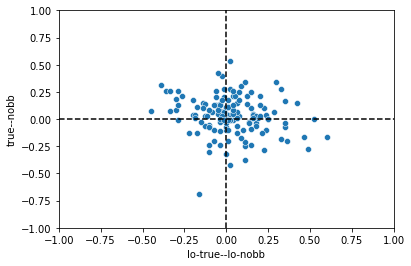

kind,Competition Series,lo-nobb,lo-truebb,nobb,selfbb,truebb,self--nobb,true--nobb,self--truebb,abs-self--truebb,abs-self--nobb,abs-true--nobb,lo-true--lo-nobb
194,23034,0.6875,0.7125,0.3125,0.7125,0.8500,0.4000,0.5375,-0.1375,0.1375,0.4000,0.5375,0.0250
178,23018,0.6875,0.6375,0.2625,0.5125,0.6875,0.2500,0.4250,-0.1750,0.1750,0.2500,0.4250,-0.0500
118,21038,0.5625,0.5375,0.3875,0.4375,0.7875,0.0500,0.4000,-0.3500,0.3500,0.0500,0.4000,-0.0250
334,27014,0.5125,0.8125,0.5250,0.7125,0.8625,0.1875,0.3375,-0.1500,0.1500,0.1875,0.3375,0.3000
267,25027,0.6375,0.7500,0.4500,0.6250,0.7875,0.1750,0.3375,-0.1625,0.1625,0.1750,0.3375,0.1125
47,20007,0.6375,0.2500,0.5625,0.7500,0.8750,0.1875,0.3125,-0.1250,0.1250,0.1875,0.3125,-0.3875
185,23025,0.5250,0.6125,0.4250,0.5750,0.7250,0.1500,0.3000,-0.1500,0.1500,0.1500,0.3000,0.0875


In [7]:
dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind", "Comparator Series"],
].copy().round()
piv = dfx.groupby(["Competition Series", "kind"]).mean().reset_index().pivot(
    index="Competition Series", columns="kind", values="Focal Prevalence"
).reset_index()
piv["self--nobb"] = piv["selfbb"] - piv["nobb"]
piv["true--nobb"] = piv["truebb"] - piv["nobb"]
piv["self--truebb"] = piv["selfbb"] - piv["truebb"]
piv["abs-self--truebb"] = np.abs(piv["self--truebb"])
piv["abs-self--nobb"] = np.abs(piv["self--nobb"])
piv["abs-true--nobb"] = np.abs(piv["true--nobb"])
piv["lo-true--lo-nobb"] = piv["lo-truebb"] - piv["lo-nobb"]
with tp.teed(
    sns.scatterplot,
    piv[
        (piv["nobb"] > 0.25) & (piv["nobb"] < 0.75)
        & (piv["lo-nobb"] > 0.25) & (piv["lo-nobb"] < 0.75)
    ],
    y="true--nobb",
    x="lo-true--lo-nobb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_ylim(-1, 1)
    ax.set_xlim(-1, 1)
    pass

piv[
    (piv["nobb"] > 0.25) & (piv["nobb"] < 0.75)
    & (piv["lo-nobb"] > 0.25) & (piv["lo-nobb"] < 0.75)
].nlargest(7, "true--nobb")


['nobb' 'selfbb' 'truebb' 'lo-nobb' 'lo-truebb']
teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=lo-true-lo-nobb+y=flip-lo-true-lo-nobb+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=lo-true-lo-nobb+y=flip-lo-true-lo-nobb+ext=.png


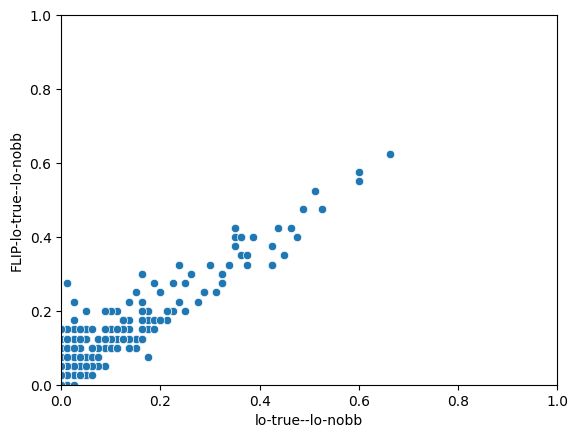

teeplots/2026-08-13-eco-gwas-weakstrong/hue=flip-lo-true-lo-nobb+viz=scatterplot+x=true-nobb+y=lo-true-lo-nobb+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/hue=flip-lo-true-lo-nobb+viz=scatterplot+x=true-nobb+y=lo-true-lo-nobb+ext=.png


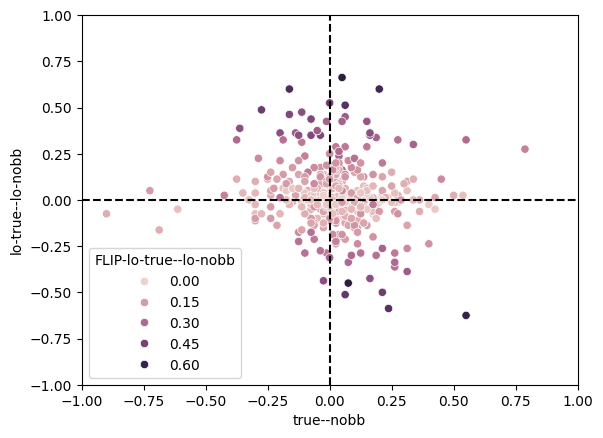

teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=true-nobb+y=lo-true-lo-nobb+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=true-nobb+y=lo-true-lo-nobb+ext=.png


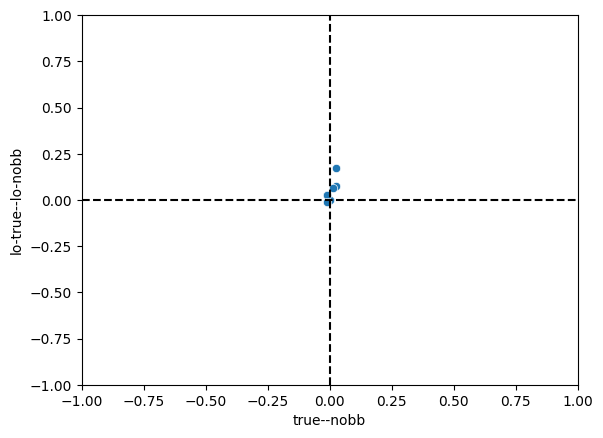

teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=nobb+y=lo-nobb+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/viz=scatterplot+x=nobb+y=lo-nobb+ext=.png


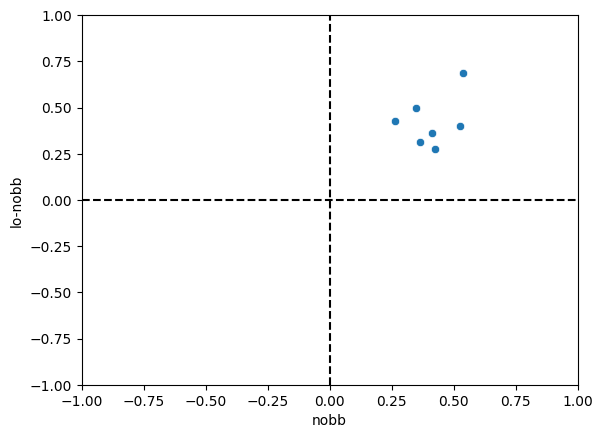

kind,Competition Series,Comparator Series,lo-nobb,lo-truebb,nobb,selfbb,truebb,FLIP-lo-true--lo-nobb,FLIP-true--nobb,self--nobb,true--nobb,self--truebb,abs-self--truebb,abs-self--nobb,abs-true--nobb,lo-true--lo-nobb,absabs,maxabsabs
67,20027,20019.5,0.5000,0.5750,0.3500,0.9000,0.3750,0.050,0.025,0.5500,0.0250,0.5250,0.5250,0.5500,0.0250,0.0750,0.1000,0.0750
131,22011,22019.5,0.3125,0.3375,0.3625,0.4750,0.3500,0.050,0.050,0.1125,-0.0125,0.1250,0.1250,0.1125,0.0125,0.0250,0.0375,0.0250
217,24017,24019.5,0.4250,0.4250,0.2625,0.3000,0.2625,0.025,0.075,0.0375,0.0000,0.0375,0.0375,0.0375,0.0000,0.0000,0.0000,0.0000
236,24036,24019.5,0.3625,0.5375,0.4125,0.8375,0.4375,0.075,0.075,0.4250,0.0250,0.4000,0.4000,0.4250,0.0250,0.1750,0.2000,0.1750
305,26025,26019.5,0.6875,0.7500,0.5375,0.5500,0.5500,0.075,0.025,0.0125,0.0125,0.0000,0.0000,0.0125,0.0125,0.0625,0.0750,0.0625
312,26032,26019.5,0.4000,0.4250,0.5250,0.4375,0.5125,0.050,0.050,-0.0875,-0.0125,-0.0750,0.0750,0.0875,0.0125,0.0250,0.0375,0.0250
350,27030,27019.5,0.2750,0.2625,0.4250,0.5375,0.4125,0.050,0.075,0.1125,-0.0125,0.1250,0.1250,0.1125,0.0125,-0.0125,0.0250,0.0125


In [8]:
dfx = df_ecoselfcontext.loc[
    (df_ecoselfcontext["Root ID"] == 0),
    ["Competition Series","Focal Prevalence", "kind", "Comparator Series"],
].copy().round()
print(dfx["kind"].unique())

piv = dfx.groupby(["Competition Series", "Comparator Series", "kind"]).mean(numeric_only=True).reset_index(drop=False).pivot(
    index=["Competition Series", "Comparator Series"], columns="kind", values="Focal Prevalence"
).reset_index()

piv["FLIP-lo-true--lo-nobb"] = np.abs(piv["lo-truebb"] - piv["lo-nobb"]) == 1
piv["FLIP-true--nobb"] = np.abs(piv["truebb"] - piv["nobb"]) == 1

piv = piv.groupby(["Competition Series"]).mean().reset_index()

piv["self--nobb"] = piv["selfbb"] - piv["nobb"]
piv["true--nobb"] = piv["truebb"] - piv["nobb"]
piv["self--truebb"] = piv["selfbb"] - piv["truebb"]
piv["abs-self--truebb"] = np.abs(piv["self--truebb"])
piv["abs-self--nobb"] = np.abs(piv["self--nobb"])
piv["abs-true--nobb"] = np.abs(piv["true--nobb"])
piv["lo-true--lo-nobb"] = piv["lo-truebb"] - piv["lo-nobb"]
piv["absabs"] = np.abs(piv["lo-true--lo-nobb"]) + np.abs(piv["true--nobb"])
piv["maxabsabs"] = np.maximum(np.abs(piv["lo-true--lo-nobb"]), np.abs(piv["true--nobb"]))


with tp.teed(
    sns.scatterplot,
    piv,
    x="lo-true--lo-nobb",
    y="FLIP-lo-true--lo-nobb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    pass

with tp.teed(
    sns.scatterplot,
    piv,
    y="lo-true--lo-nobb",
    x="true--nobb",
    hue="FLIP-lo-true--lo-nobb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_ylim(-1, 1)
    ax.set_xlim(-1, 1)
    pass

xtract = piv[
    (piv["FLIP-lo-true--lo-nobb"] < 0.1)
    & (piv["FLIP-true--nobb"] < 0.1)
    & (0.25 < piv["nobb"]) & (piv["nobb"] < 0.75)
    & (0.25 < piv["lo-nobb"]) & (piv["lo-nobb"] < 0.75)
    & (piv["abs-true--nobb"] < 0.05)
]

with tp.teed(
    sns.scatterplot,
    xtract,
    y="lo-true--lo-nobb",
    x="true--nobb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_ylim(-1, 1)
    ax.set_xlim(-1, 1)
    pass

with tp.teed(
    sns.scatterplot,
    xtract,
    y="lo-nobb",
    x="nobb",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_ylim(-1, 1)
    ax.set_xlim(-1, 1)
    pass

xtract


# test


In [9]:
bucket = "prq49-20stint"
dfs = []
for suffix in [
    "-backgroundbb",
    "-focalbb",

]:
    prefix = ""
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    # https://github.com/mmore500/oee4/blob/4cc2305ffdf41b5335875e9074e17773af47e734/binder/2026-07-25-ecoselfcontext-pgcomplex-screen.ipynb
    stint = 0
    for endeavor in tqdm([17, *range(20, 29)]):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor={endeavor}/{prefix}variant-competitions-lowestroot{suffix}/stage=4+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df["Stint"] = stint
            df["Series"] = df["Competition Series"]
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            assert "Series" in df.columns, df.columns

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            df["how"] = suffix.strip("-") if suffix else "none"
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}, {suffix=}, {endeavor=}")
            raise e

print(len(dfs), "dataframes loaded")


100%|██████████| 10/10 [00:03<00:00,  2.61it/s]

20 dataframes loaded


In [10]:
df = pd.concat(dfs)


In [11]:
classifications = {
    24017: "mild",
    27030: "mild",
    26032: "mild",
    22011: "mild",
    26025: "mild",
    20027: "mild",
    24036: "mild",
    23034: "strong",
    23018: "strong",
    21038: "strong",
    27014: "strong",
    25027: "strong",
    20007: "strong",
    23025: "strong",
    # 17020: "strong",  # match to mild nsamp
    # 23039: "strong",
    # 24010: "strong",
}


In [12]:
df = df[df["Series"].isin(classifications.keys())].copy()
df["classification"] = df["Series"].map(classifications)


In [13]:
pd.options.display.max_columns = None


In [14]:
dfx = df[df["Root ID"] == 1]
dfx["site"] = dfx["genome variation"].str.extract(r'i(\d+)%')


In [15]:
palette = ["#65952f", "#797979"]


teeplots/2026-08-13-eco-gwas-weakstrong/col=classification+hue=classification+style=classification+viz=relplot+x=focal-prevalence-backgroundbb+y=focal-prevalence-focalbb+ythresh=0.45+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/col=classification+hue=classification+style=classification+viz=relplot+x=focal-prevalence-backgroundbb+y=focal-prevalence-focalbb+ythresh=0.45+ext=.png


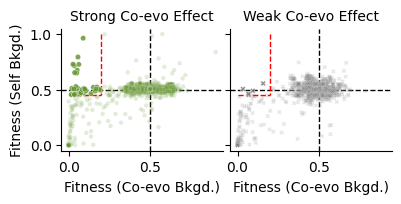

teeplots/2026-08-13-eco-gwas-weakstrong/col=classification+hue=classification+style=classification+viz=relplot+x=focal-prevalence-backgroundbb+y=focal-prevalence-focalbb+ythresh=0.5+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/col=classification+hue=classification+style=classification+viz=relplot+x=focal-prevalence-backgroundbb+y=focal-prevalence-focalbb+ythresh=0.5+ext=.png


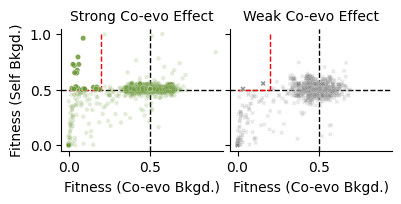

In [16]:
for ythresh in [0.45, 0.5]:

    # 1. Pivot the data
    dat = dfx.pivot(
        index=["Series", "classification", "site"],
        columns=["how"],
        values=["Focal Prevalence"],
    ).reset_index()

    # 2. FLATTEN the MultiIndex columns
    dat.columns = [
        f"{col[0]}_{col[1]}".strip("_") if isinstance(col, tuple) else col
        for col in dat.columns
    ]

    # Extract unique classes to force uniform colors/markers across all layers
    classes = dat["classification"].unique()

    with tp.teed(
        sns.relplot,
        data=dat,
        x="Focal Prevalence_backgroundbb",
        y="Focal Prevalence_focalbb",
        hue="classification",
        style="classification",
        alpha=0.18,
        col="classification",
        hue_order=classes,
        style_order=classes,
        legend=False,
        s=10,
        palette=palette,
        teeplot_outattrs={"ythresh": ythresh},
        teeplot_subdir=teeplot_subdir
    ) as g:

        thresh = 0.2

        # 4. Custom function to filter and plot points
        def plot_high_alpha(data, x, y, hue, style, **kwargs):
            # map_dataframe automatically passes 'color' and 'label' to kwargs.
            # We must remove them so they don't clash with sns.scatterplot's internal hue mapping.
            kwargs.pop("color", None)
            kwargs.pop("label", None)

            subset = data[(data[x] < thresh) & (data[y] >= ythresh)]
            if not subset.empty:
                sns.scatterplot(
                    data=subset,
                    x=x,
                    y=y,
                    hue=hue,
                    palette=palette,
                    style=style,
                    **kwargs
                )

        # 5. Map the custom function
        g.map_dataframe(
            plot_high_alpha,
            x="Focal Prevalence_backgroundbb",
            y="Focal Prevalence_focalbb",
            hue="classification",
            style="classification",
            hue_order=classes,
            style_order=classes,
            alpha=0.8,     # High alpha for emphasis
            legend=False,  # Prevent duplicate entries in the legend
            zorder=5,       # Ensure these points draw on top of the low-alpha ones
            s=15,
        )

        # 6. Add custom lines
        for ax in g.axes.flatten():
            ax.axhline(0.5, ls="--", color="black", lw=1, zorder=-1)
            ax.axvline(0.5, ls="--", color="black", lw=1, zorder=-1)
            ax.plot((thresh, thresh), (1.0, ythresh), ls="--", color="red", lw=1, zorder=4)
            ax.plot((0, thresh), (ythresh, ythresh), ls="--", color="red", lw=1, zorder=4)

        g.axes.flatten()[0].set_title("Strong Co-evo Effect", fontsize="medium")
        g.axes.flatten()[1].set_title("Weak Co-evo Effect", fontsize="medium")
        g.set(xlabel="Fitness (Co-evo Bkgd.)", ylabel="Fitness (Self Bkgd.)")

        g.figure.set_size_inches(3.6, 1.5)


teeplots/2026-08-13-eco-gwas-weakstrong/color=white+viz=boxplot+x=classification+y=count+ythresh=0.45+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/color=white+viz=boxplot+x=classification+y=count+ythresh=0.45+ext=.png


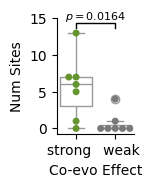

,classification,Series,count
0,mild,20027,1
1,mild,22011,0
2,mild,24017,0
3,mild,24036,0
4,mild,26025,0
5,mild,26032,4
6,mild,27030,0
7,strong,20007,6
8,strong,21038,7
9,strong,23018,7


MannwhitneyuResult(statistic=6.0, pvalue=0.016413451182180513)

(-0.7551020408163265, 'large')

teeplots/2026-08-13-eco-gwas-weakstrong/color=white+viz=boxplot+x=classification+y=count+ythresh=0.5+ext=.pdf
teeplots/2026-08-13-eco-gwas-weakstrong/color=white+viz=boxplot+x=classification+y=count+ythresh=0.5+ext=.png


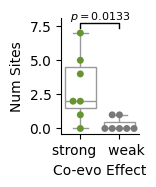

,classification,Series,count
0,mild,20027,1
1,mild,22011,0
2,mild,24017,0
3,mild,24036,0
4,mild,26025,0
5,mild,26032,1
6,mild,27030,0
7,strong,20007,5
8,strong,21038,2
9,strong,23018,4


MannwhitneyuResult(statistic=5.5, pvalue=0.013318275975344)

(-0.7755102040816326, 'large')

In [17]:
for ythresh in [0.45, 0.5]:

    # 1. Define your condition
    condition = (dat["Focal Prevalence_backgroundbb"] < 0.2) & (dat["Focal Prevalence_focalbb"] >= ythresh)

    # 2. Assign as a temporary column, group the whole dataframe, and sum
    result = (
        dat.assign(meets_condition=condition)
        .groupby(["classification", "Series"])["meets_condition"]
        .sum()
        .astype(int) # Converts the sum back to standard integers
        .reset_index(name="count")
    )

    stat = scipy_stats.mannwhitneyu(
        *[
            group["count"].values
            for name, group in result.groupby("classification")
        ],
    )

    delta = cliffs_delta(
        *[
            group["count"].values
            for name, group in result.groupby("classification")
        ],
    )

    with tp.teed(
        sns.boxplot,
        data=result.replace({"mild": "weak"}),
        x="classification",
        y="count",
        color="white",
        order=["strong", "weak"],
        teeplot_outattrs={"ythresh": ythresh},
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        sns.swarmplot(
            data=result.replace({"mild": "weak"}),
            x="classification",
            y="count",
            palette=palette,
            size=5,
            order=["strong", "weak"],
        )
        ax.figure.set_size_inches(1, 1.5)
        sns.despine(ax=ax, top=True, right=True)
        ax.set_ylabel("Num Sites")
        ax.set_xlabel("Co-evo Effect")
        ax.tick_params(axis="both", labelsize=10)
        ax.set_xticklabels(["strong   ", "   weak"])

        # annotation
        y_max = result['count'].max()
        h = y_max * 0.05
        y_line = y_max + h * 2

        # Draw the bracket: [x-coords], [y-coords]
        ax.plot([0, 0, 1, 1], [y_line - h, y_line, y_line, y_line - h], lw=1, c='black')

        # Add the p-value text above the center of the bracket
        ax.text(
            0.5,
            y_line,
            f"$p = {stat.pvalue:.3g}$",
            ha="center",
            va="bottom",
            color="black",
            fontsize=8,
        )


    display(result, stat, delta)
